In [30]:
from tensorflow import keras
from keras.datasets import mnist
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [15]:
df = pd.DataFrame(x_train.reshape(x_train.shape[0],x_train.shape[1] * x_train.shape[2])) #6000, 784
df.head(5)

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


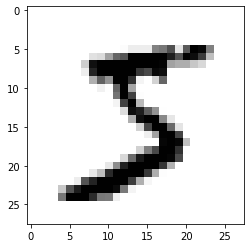

In [16]:
plt.imshow(x_train[0], cmap="gray_r")

In [18]:
model = keras.Sequential()
model.add(keras.layers.Dense(64, activation="relu", input_shape=(784,)))
model.add(keras.layers.Dense(10, activation="softmax"))

In [19]:
model.compile(optimizer="rmsprop", loss="categorical_crossentropy", metrics=["accuracy"])

In [20]:
x_train=x_train.reshape(x_train.shape[0],x_train.shape[1]*x_train.shape[2])
x_test=x_test.reshape(x_test.shape[0],x_test.shape[1]*x_test.shape[2])

y_train=keras.utils.to_categorical(y_train, 10)
y_test=keras.utils.to_categorical(y_test, 10)

amogus = model.fit(x_train, y_train, epochs=5, batch_size=32, validation_data=(x_test, y_test))

Epoch 1/5
1875/1875 [==============================] - 3s 1ms/step - loss: 2.2875 - accuracy: 0.8435 - val_loss: 0.5916 - val_accuracy: 0.8990
Epoch 2/5
1875/1875 [==============================] - 3s 1ms/step - loss: 0.5493 - accuracy: 0.9125 - val_loss: 0.5094 - val_accuracy: 0.9256
Epoch 3/5
1875/1875 [==============================] - 3s 1ms/step - loss: 0.4684 - accuracy: 0.9278 - val_loss: 0.5373 - val_accuracy: 0.9241
Epoch 4/5
1875/1875 [==============================] - 3s 1ms/step - loss: 0.4438 - accuracy: 0.9345 - val_loss: 0.5857 - val_accuracy: 0.9268
Epoch 5/5
1875/1875 [==============================] - 3s 1ms/step - loss: 0.4298 - accuracy: 0.9366 - val_loss: 0.5678 - val_accuracy: 0.9276


In [21]:
amogus.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

In [22]:
acc = amogus.history["accuracy"]
loss = amogus.history["loss"]
val_loss = amogus.history["val_loss"]
val_acc = amogus.history["val_accuracy"]

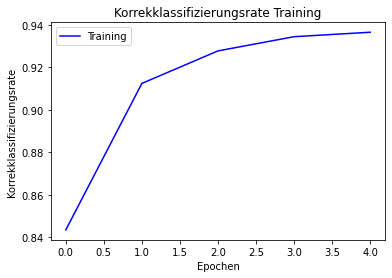

In [23]:
plt.plot(acc, 'b', label="Training")
plt.title("Korrekklassifizierungsrate Training")
plt.xlabel("Epochen")
plt.ylabel("Korrekklassifizierungsrate")
plt.legend()
plt.show()

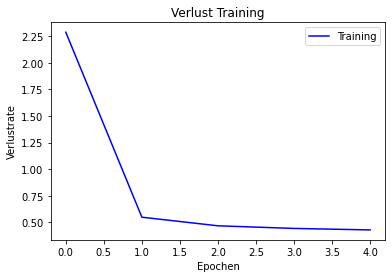

In [24]:
plt.plot(loss, 'b', label="Training")
plt.title("Verlust Training")
plt.xlabel("Epochen")
plt.ylabel("Verlustrate")
plt.legend()
plt.show()


In [26]:
model.save("migger1")
keras.backend.clear_session()
model = keras.models.load_model("migger1")

INFO:tensorflow:Assets written to: migger1\assets


In [27]:
testarg = np.argmax(y_test, axis=1)
y_pred = model.predict(x_test)
predarg = np.argmax(y_pred, axis=1)
pd.crosstab(testarg, predarg, rownames=['actual'], colnames=['pred'])

pred,0,1,2,3,4,5,6,7,8,9
actual,,,,,,,,,,
0,943,2,2,2,0,0,3,5,19,4
1,0,1105,3,1,0,3,2,0,19,2
2,5,4,942,11,3,1,1,5,59,1
3,1,0,17,909,0,16,0,7,58,2
4,1,5,3,0,867,0,8,5,41,52
5,4,0,0,19,1,805,13,5,39,6
6,6,2,1,1,11,5,913,0,19,0
7,0,4,18,18,2,2,0,944,17,23
8,4,3,3,5,8,6,0,2,933,10


In [28]:
nx_test = x_test/255
nx_train = x_train/255

model.fit(nx_train, y_train, batch_size=32, epochs=5, validation_data=(nx_test, y_test))

Epoch 1/5
1875/1875 [==============================] - 3s 1ms/step - loss: 0.2384 - accuracy: 0.9346 - val_loss: 0.1449 - val_accuracy: 0.9590
Epoch 2/5
1875/1875 [==============================] - 3s 1ms/step - loss: 0.1254 - accuracy: 0.9646 - val_loss: 0.1144 - val_accuracy: 0.9670
Epoch 3/5
1875/1875 [==============================] - 3s 1ms/step - loss: 0.0988 - accuracy: 0.9715 - val_loss: 0.1034 - val_accuracy: 0.9690
Epoch 4/5
1875/1875 [==============================] - 3s 1ms/step - loss: 0.0837 - accuracy: 0.9762 - val_loss: 0.1047 - val_accuracy: 0.9710
Epoch 5/5
1875/1875 [==============================] - 3s 1ms/step - loss: 0.0746 - accuracy: 0.9789 - val_loss: 0.1038 - val_accuracy: 0.9718


In [ ]:
img = Image.open("0.png").convert("L")
img.show()
img = np.array(img).reshape(1,784)/255
predict = model.predict(img)
np.argmax(predict, axis=1)